In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from windfreak import SynthHD
from RsInstrument import RsInstrument, BinFloatFormat

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

In [2]:
print(vna.query('*IDN?'))

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


In [4]:
with open("vna-settings.json", "r") as f:
    vna_settings = json.load(f)

vna_settings

{'idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'fstart': 4000000000.0,
 'fstop': 8000000000.0,
 'numpoints': 1001,
 'ifbw': 10000.0,
 'source_power': -30.0}

In [6]:
vna.write(f":SENS1:FREQ:START {vna_settings['fstart']}")
vna.write(f":SENS1:FREQ:STOP {vna_settings['fstop']}")
vna.write(f":SENS1:SWEep:POINts {vna_settings['numpoints']}")
vna.write(f":SENS1:BANDwidth {vna_settings['ifbw']}")
vna.write(f":SOUR1:POW {vna_settings['source_power']}")


In [7]:
vna.go_to_local()


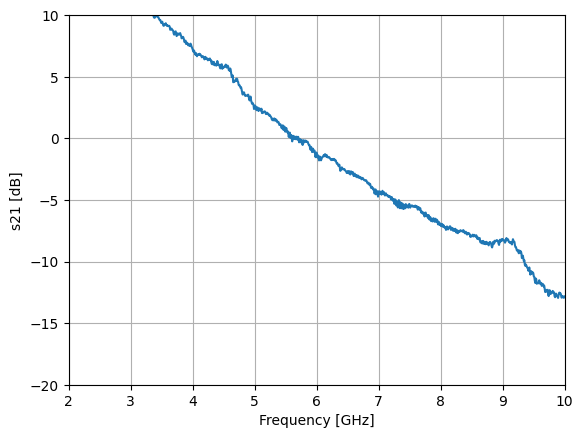

In [14]:
vna_json = {}
vna_json['idn'] = vna.query('*IDN?')
vna_json['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_json['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_json['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_json['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_json['source_power'] = float(vna.query(':SOUR1:POW?'))

frequencies = np.linspace(vna_json['fstart'],vna_json['fstop'],vna_json['numpoints'])
fghz = frequencies/1e9

vna.visa_timeout = 60000 

vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
vna.write("FORM REAL,32") 
vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
vna.write("INITiate:CONTinuous OFF")
vna.write("INITiate:IMMediate")  
opc_done = vna.query("*OPC?").strip()

if opc_done != "1":
    print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
    exit()

raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")

vna.write("INITiate:CONTinuous ON")
vna.go_to_local()

real_parts = np.array(raw_floats[0::2])
imag_parts = np.array(raw_floats[1::2])
complex_trace = real_parts + 1j * imag_parts

s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
s_matrix[:, 0, 0] = complex_trace
trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
trace = trace_network.s_db[:,0,0]

plt.plot(fghz, trace)
plt.xlim(fghz[0], fghz[-1])
plt.ylim(-20, 10)
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s21 [dB]')
plt.savefig('vna-trace.png', dpi=300, bbox_inches='tight')

plt.show()
trace_network.write('vna-trace.s1p')
with open('vna-settings.json', 'w') as json_file:
    json.dump(vna_json, json_file, indent=4)

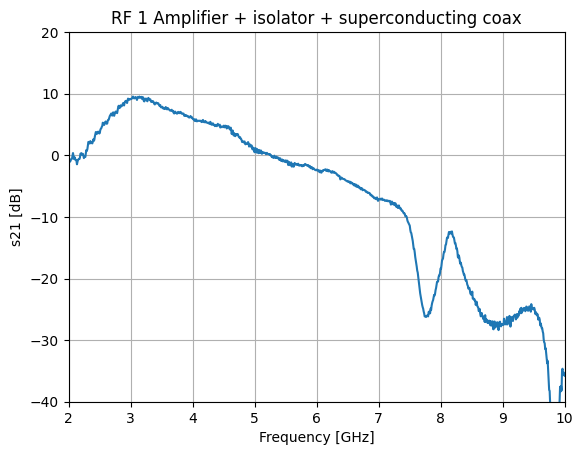

In [13]:
plt.plot(fghz, trace)
plt.xlim(fghz[0], fghz[-1])
plt.ylim(-40, 20)
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s21 [dB]')
plt.title('RF 1 Amplifier + isolator + superconducting coax')
plt.savefig('vna-trace-rfout1-amp-isolator.png', dpi=300, bbox_inches='tight')

plt.show()
trace_network.write('vna-trace-rfout1-amp-isolator.s1p')
with open('vna-settings-rfout1-amp-isolator.json', 'w') as json_file:
    json.dump(vna_json, json_file, indent=4)

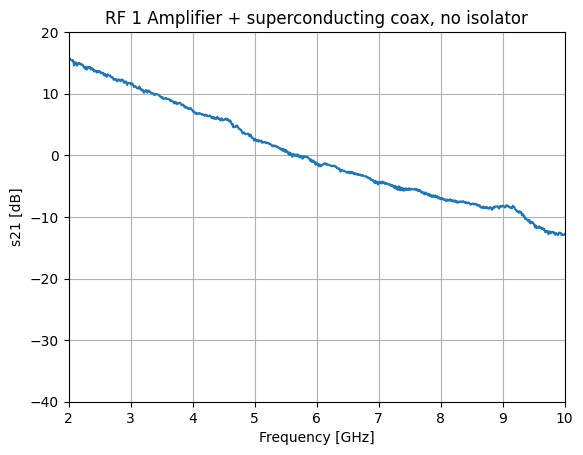

In [16]:
plt.plot(fghz, trace)
plt.xlim(fghz[0], fghz[-1])
plt.ylim(-40, 20)
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s21 [dB]')
plt.title('RF 1 Amplifier + superconducting coax, no isolator')
plt.savefig('vna-trace-rfout1-amp-no-isolator.png', dpi=300, bbox_inches='tight')